In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
train_df = pd.read_csv('train.csv', dtype={'StateHoliday': str})
store_df = pd.read_csv('store.csv')
print(f"Train shape: {train_df.shape}")
print(f"Store shape: {store_df.shape}")
print(f"\nFirst few rows:")
print(train_df.head())
pd.set_option('display.max_columns',None)
train_df['Date'] = pd.to_datetime(train_df['Date'])
print(f'\nDate range: {train_df.min()} to {train_df.max()}')
print(f'\nDuration: {(train_df['Date'].max() - train_df['Date'].min()).days}')
print(f'Number of stores: {train_df['Store'].nunique()}')
print(f'total observation {len(train_df):,}')
print(f'\nColumn info: {train_df.info()}')

Train shape: (1017209, 9)
Store shape: (1115, 10)

First few rows:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  

Date range: Store                              1
DayOfWeek                          1
Date             2013-01-01 00:00:00
Sales                              0
Customers                          0
Open                               0
Promo                              0
StateHoliday                       0
SchoolHoliday                      

In [2]:
daily_sales = train_df.groupby('Date')['Sales'].agg(['sum','mean','count']).reset_index()
daily_sales.columns = ['Date','TotalSales','AvgSales','StoresOpen']
print("=== DAILY SALES SUMMARY ===")
print(daily_sales.head(10))
print(f"\nStats:")
print(daily_sales.describe())


=== DAILY SALES SUMMARY ===
        Date  TotalSales     AvgSales  StoresOpen
0 2013-01-01       97235    87.284560        1114
1 2013-01-02     6949829  6233.030493        1115
2 2013-01-03     6347820  5693.112108        1115
3 2013-01-04     6638954  5954.218834        1115
4 2013-01-05     5951593  5337.751570        1115
5 2013-01-06      143904   129.061883        1115
6 2013-01-07    10826848  9710.177578        1115
7 2013-01-08     8749437  7847.028700        1115
8 2013-01-09     7746603  6947.626009        1115
9 2013-01-10     7751485  6952.004484        1115

Stats:
                      Date    TotalSales      AvgSales   StoresOpen
count                  942  9.420000e+02    942.000000   942.000000
mean   2014-04-16 12:00:00  6.234799e+06   5782.702036  1079.839703
min    2013-01-01 00:00:00  9.723500e+04     87.284560   935.000000
25%    2013-08-24 06:00:00  5.675832e+06   5321.408512  1115.000000
50%    2014-04-16 12:00:00  6.580354e+06   6036.153617  1115.000000
75%   

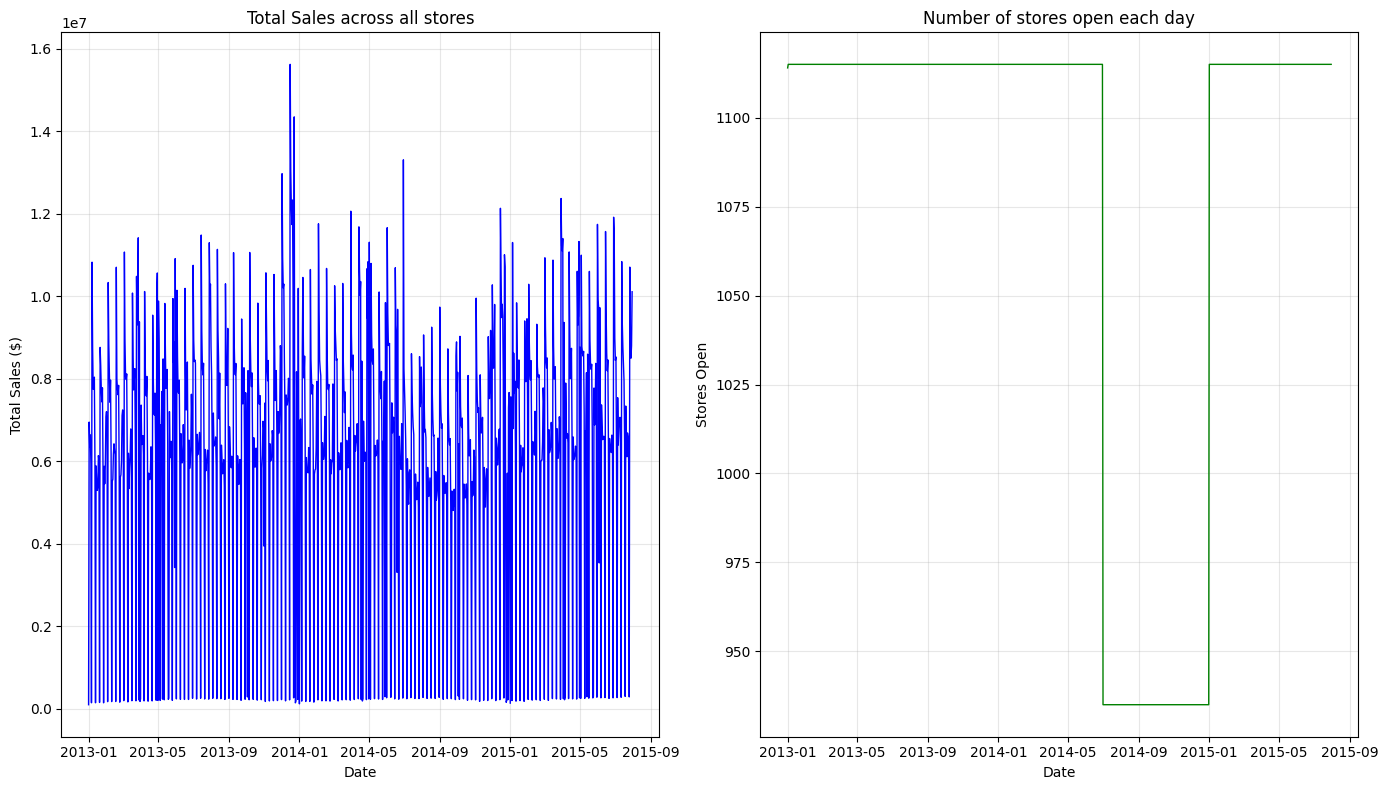

In [3]:
fig,axes = plt.subplots(1,2,figsize = (14,8))

axes[0].plot(daily_sales['Date'],daily_sales['TotalSales'],linewidth = 1,color = 'blue')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_title('Total Sales across all stores')
axes[0].grid(alpha=0.3)

axes[1].plot(daily_sales['Date'],daily_sales['StoresOpen'],linewidth = 1 ,color = 'green')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Stores Open')
axes[1].set_title('Number of stores open each day')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Weekly Seasonality ===
DayName
Monday       7828.585262
Tuesday      7022.591726
Wednesday    6561.618318
Thursday     6265.341800
Friday       6721.988769
Saturday     5847.518765
Sunday        205.592506
Name: AvgSales, dtype: float64


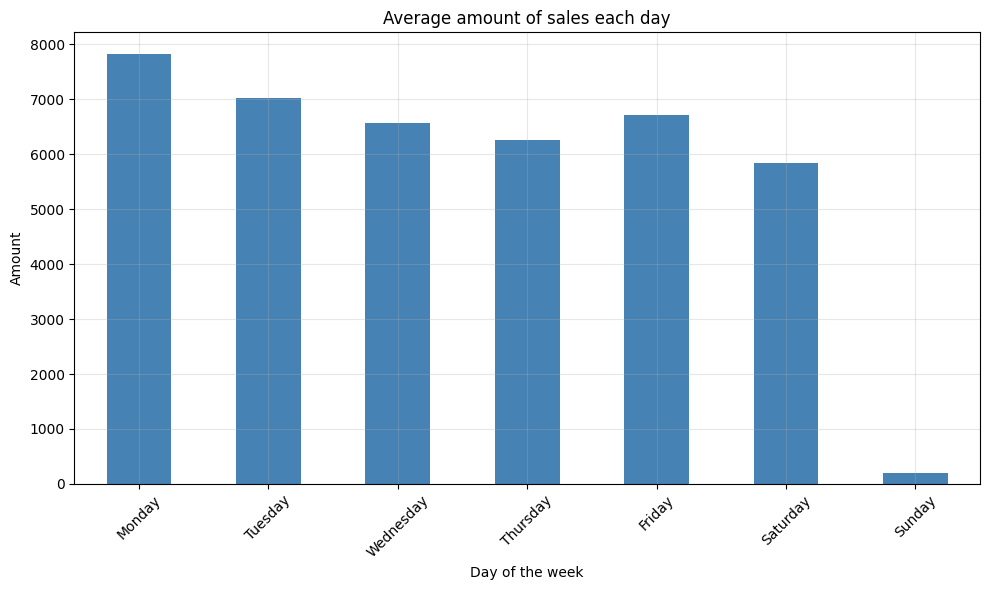

In [4]:
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek
daily_sales['DayName'] = daily_sales['Date'].dt.day_name()

weekly_patern = daily_sales.groupby('DayName')['AvgSales'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print('=== Weekly Seasonality ===')
print(weekly_patern)

fig,ax = plt.subplots(figsize = (10, 6))

weekly_patern.plot(kind = 'bar',ax=ax,color = 'steelblue')
ax.set_xlabel('Day of the week')
ax.set_ylabel('Amount')
ax.set_title('Average amount of sales each day')
ax.grid(alpha = 0.3)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [5]:
train_full = train_df.merge(store_df,on='Store',how='left')
print('=== merged data ===')
print('shape of the merged data: ',train_full.shape)
print('new columns: ',train_full.columns.tolist())
print('first few rows: ')
print(train_full.head())

print('=== store types ===')
print(train_full['StoreType'].value_counts())
print('Average sales by each store')
print(train_full.groupby('StoreType')['Sales'].mean().sort_values(ascending = False))

print('Check if there are any missing data')
missing = train_full.isnull().sum()
print(missing[missing>0])

=== merged data ===
shape of the merged data:  (1017209, 18)
new columns:  ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
first few rows: 
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3          5 2015-07-31   8314        821     1      1            0   
3      4          5 2015-07-31  13995       1498     1      1            0   
4      5          5 2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a   

In [6]:
print('closed days of week: ')
print(train_full[train_full['Open'] == 0]['DayOfWeek'].value_counts().sort_index())

store_id = 1
store_data = train_full[train_full['Store'] == store_id].copy().sort_values('Date')
print(f'store {store_id} analysis')
print(f'observation {len(store_data)}')
print(f'Date range: {store_data['Date'].min()} to {store_data['Date'].max()}')
print(f'Average daily sales {store_data['Sales'].mean():.2f}')
print(f'Sales Range from {store_data['Sales'].min():,}$ to {store_data['Sales'].max():,}$')

closed days of week: 
DayOfWeek
1      7170
2      1703
3      3729
4     11201
5      7205
6       672
7    141137
Name: count, dtype: int64
store 1 analysis
observation 942
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Average daily sales 3945.70
Sales Range from 0$ to 9,528$


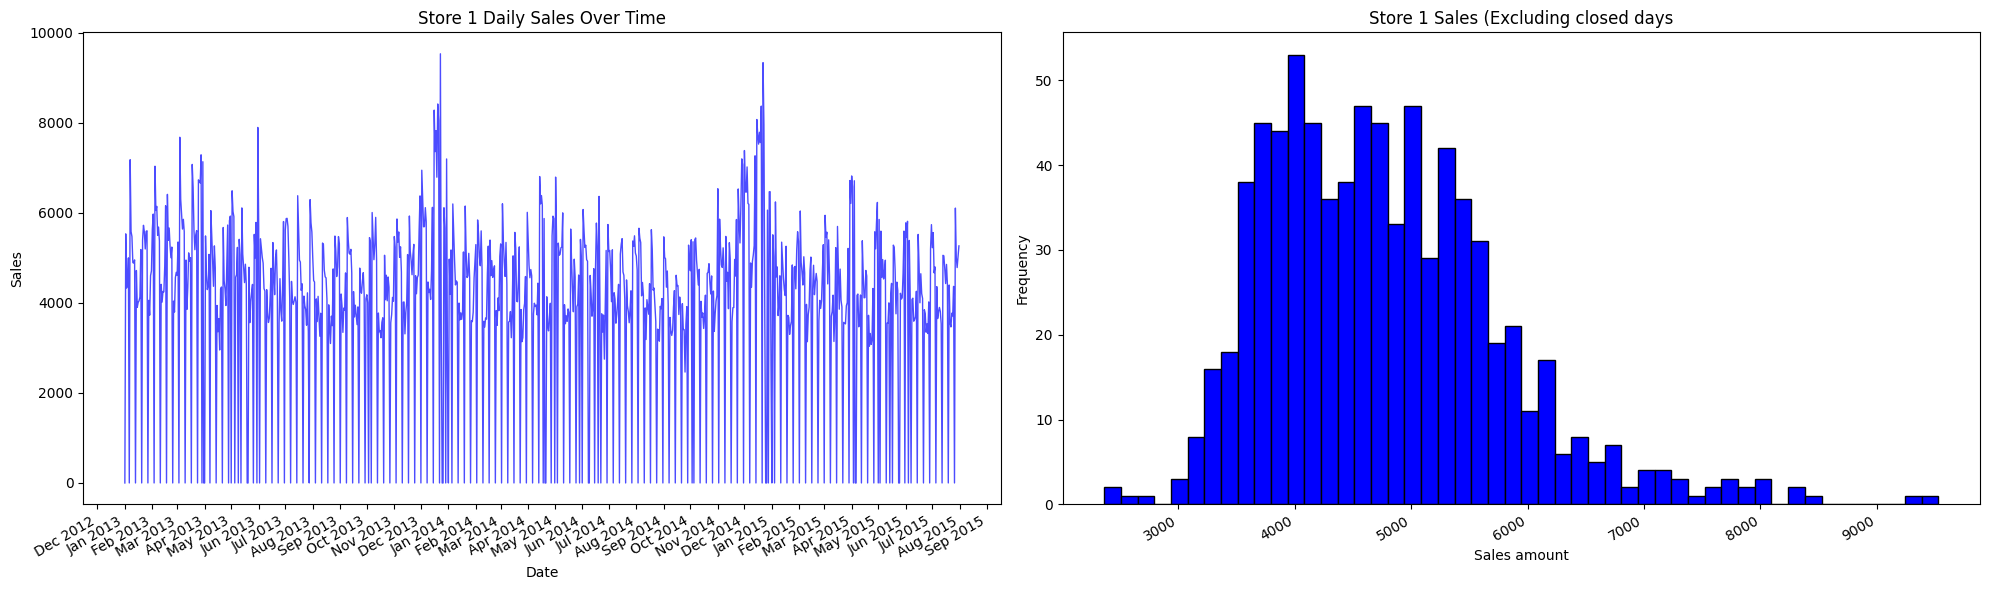

In [7]:
fig,ax = plt.subplots(1,2,figsize = (20,6))
ax[0].plot(store_data['Date'],store_data['Sales'],linewidth = 1,alpha = 0.7,color = 'blue')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Sales')
ax[0].set_title(f'Store {store_id} Daily Sales Over Time')
import matplotlib.dates as mdates


ax[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
fig.autofmt_xdate() 
ax[1].hist(store_data[store_data['Sales']>0]['Sales'],bins = 50,color = 'blue',edgecolor = 'black')
ax[1].set_xlabel('Sales amount')
ax[1].set_ylabel('Frequency')
ax[1].set_title(f'Store {store_id} Sales (Excluding closed days')
plt.tight_layout()
plt.show()

## Day 1: Time Series Exploration Summary

### Dataset Overview
- **1,017,209 observations** across 1,115 stores
- **Date range:** 2013-01-01 to 2015-07-31 (942 days, 2.5 years)
- **Missing data:** Competition info (32%), Promo2 (50%) - expected

### Weekly Seasonality Pattern
- **Monday: €7,828/store** - Highest (people stock up start of week)
- **Sunday: €205/store** - 97% lower (most stores closed)
- Clear 7-day cycle dominates the data

### Store Type Analysis
- **Type b:** €10,058 avg (premium stores, rare)
- **Type a:** €5,738 avg (most common, 54% of data)
- 75% sales difference between best and worst store types

### Key Patterns Discovered
1. **Strong weekly seasonality** - Monday peak, Sunday valley
2. **Holiday spikes** - Christmas 2013/2014 sales 2-3x normal
3. **82% of closures on Sundays** - cultural pattern
4. **No strong long-term trend** - sales relatively stable over 2.5 years

### Single Store Analysis (Store 1)
- Average: €3,946/day
- Range: €0 (closed) to €9,528 (Christmas)
- Distribution: Right-skewed, modal range €4,000-5,000

### Tomorrow: Trend & Seasonality Decomposition
We'll separate the trend component from seasonality to understand underlying patterns.

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

store_1 = train_full[train_full['Store'] == 1].copy().sort_values('Date')
store_1_open = train_full[train_full['Open'] == 1].copy()
store_1_open = store_1_open.set_index('Date')

print('=== seasonal decomposition setup ===')
print(f'store 1 observation (open only) {len(store_1_open)}')
print(f'Date range: {store_1_open.index.min()} to {store_1_open.index.max()}')

=== seasonal decomposition setup ===
store 1 observation (open only) 844392
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


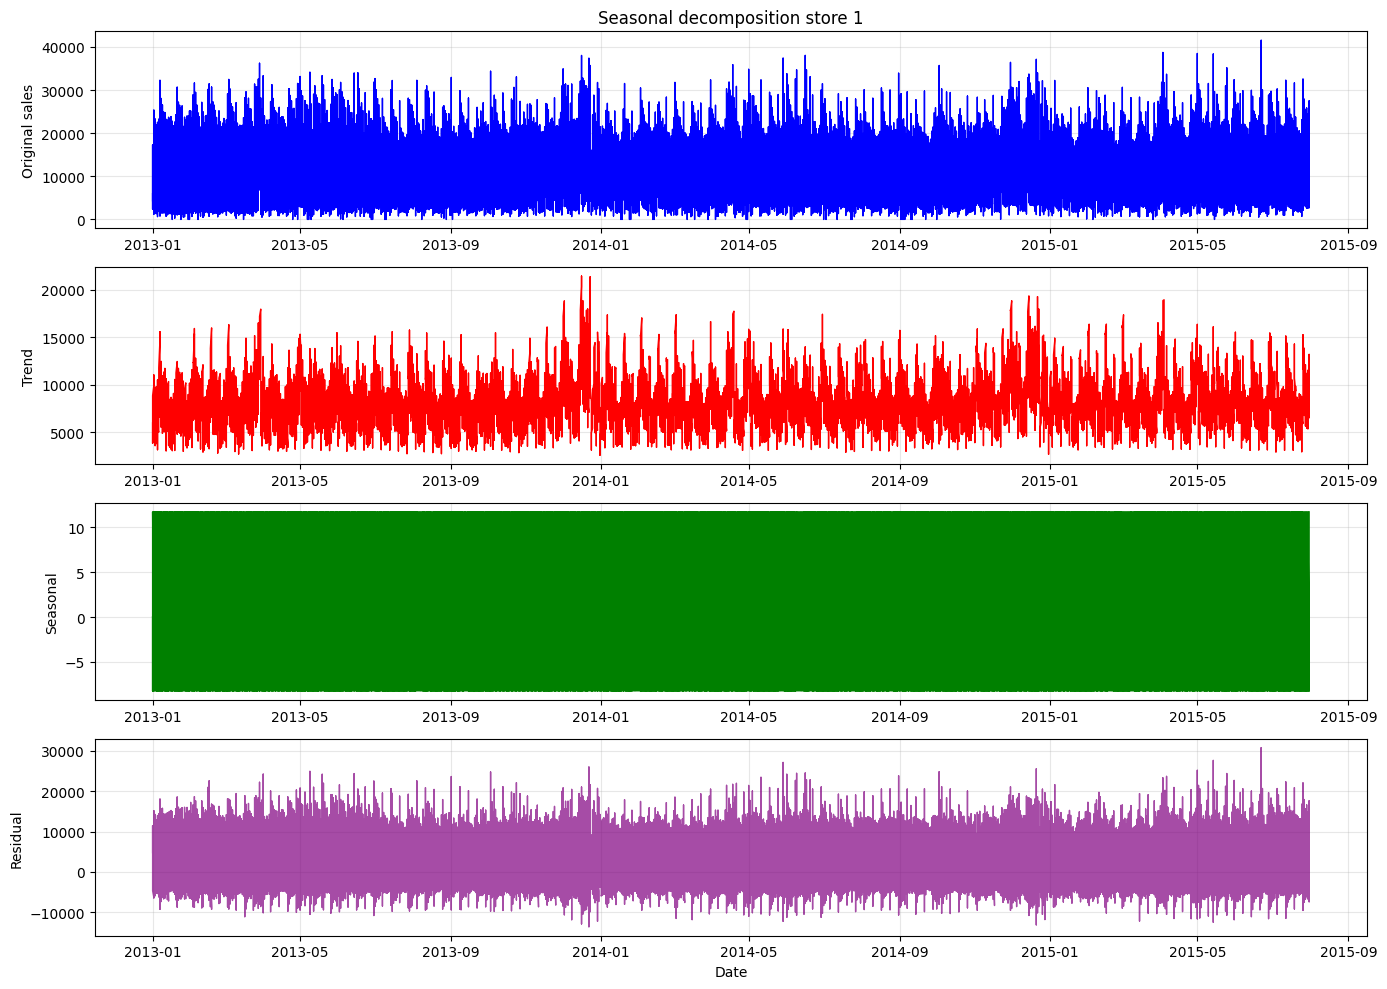


 === DECOMPOSITION STATS ===
Trend mean: 6955.52
Seasonal range from -8.25 to 11.74
Residual std: 2507.68


In [9]:
decomposition = seasonal_decompose(store_1_open['Sales'],model = 'additive',period = 7)

fig,ax = plt.subplots(4,1,figsize = (14,10))

ax[0].plot(store_1_open.index,store_1_open['Sales'],linewidth = 1,color = 'blue')
ax[0].set_ylabel('Original sales')
ax[0].set_title('Seasonal decomposition store 1')
ax[0].grid(alpha = 0.3)

ax[1].plot(decomposition.trend.index,decomposition.trend,linewidth = 1,color = 'red')
ax[1].set_ylabel('Trend')
ax[1].grid(alpha = 0.3)

ax[2].plot(decomposition.seasonal.index,decomposition.seasonal,linewidth = 1,color = 'green')
ax[2].set_ylabel('Seasonal')
ax[2].grid(alpha = 0.3)

ax[3].plot(decomposition.resid.index,decomposition.resid,linewidth = 1,color = 'purple',alpha = 0.7)
ax[3].set_ylabel('Residual')
ax[3].grid(alpha = 0.3)
ax[3].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

print('\n === DECOMPOSITION STATS ===')
print(f'Trend mean: {decomposition.trend.mean():.2f}')
print(f'Seasonal range from {decomposition.seasonal.min():.2f} to {decomposition.seasonal.max():.2f}')
print(f'Residual std: {decomposition.resid.std():.2f}')

=== WEEKLY SEASONAL DECOMPOSITION ===
Monday        +11.74 boost
Tuesday        -8.25 (penalty)
Wednesday      +0.04 boost
Thursday       +7.42 boost
Friday         -5.28 (penalty)
Saturday       -0.23 (penalty)
Sunday         -5.43 (penalty)


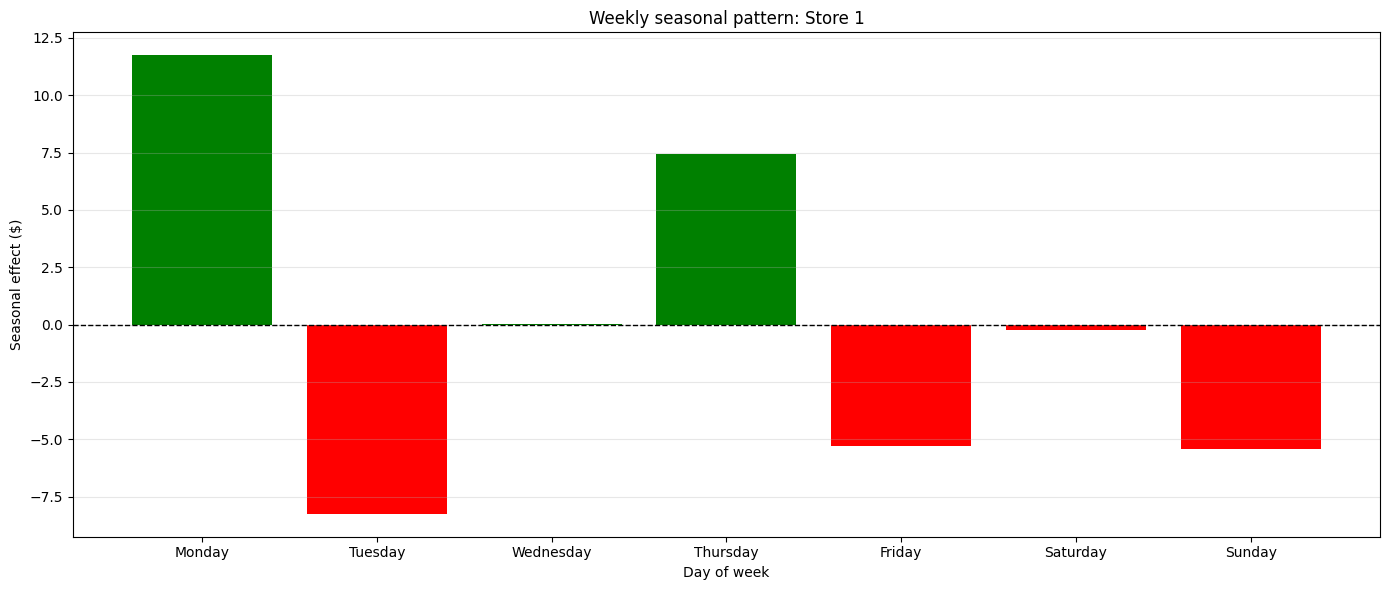

In [10]:
seasonal_pattern = decomposition.seasonal.iloc[:7].values

print('=== WEEKLY SEASONAL DECOMPOSITION ===')
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

for day,value in zip(days,seasonal_pattern):
    print(f'{day:12s} {value:+7.2f} {'boost' if value > 0 else '(penalty)'}')
fig,ax = plt.subplots(figsize = (14,6))

ax.bar(days,seasonal_pattern,color = ['green' if v > 0 else 'red' for v in seasonal_pattern])
ax.set_ylabel('Seasonal effect ($)')
ax.set_xlabel('Day of week')
ax.set_title('Weekly seasonal pattern: Store 1')
ax.axhline(y = 0,color = 'black',linestyle = '--',linewidth = 1)
ax.grid(axis = 'y',alpha = 0.3)
#plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

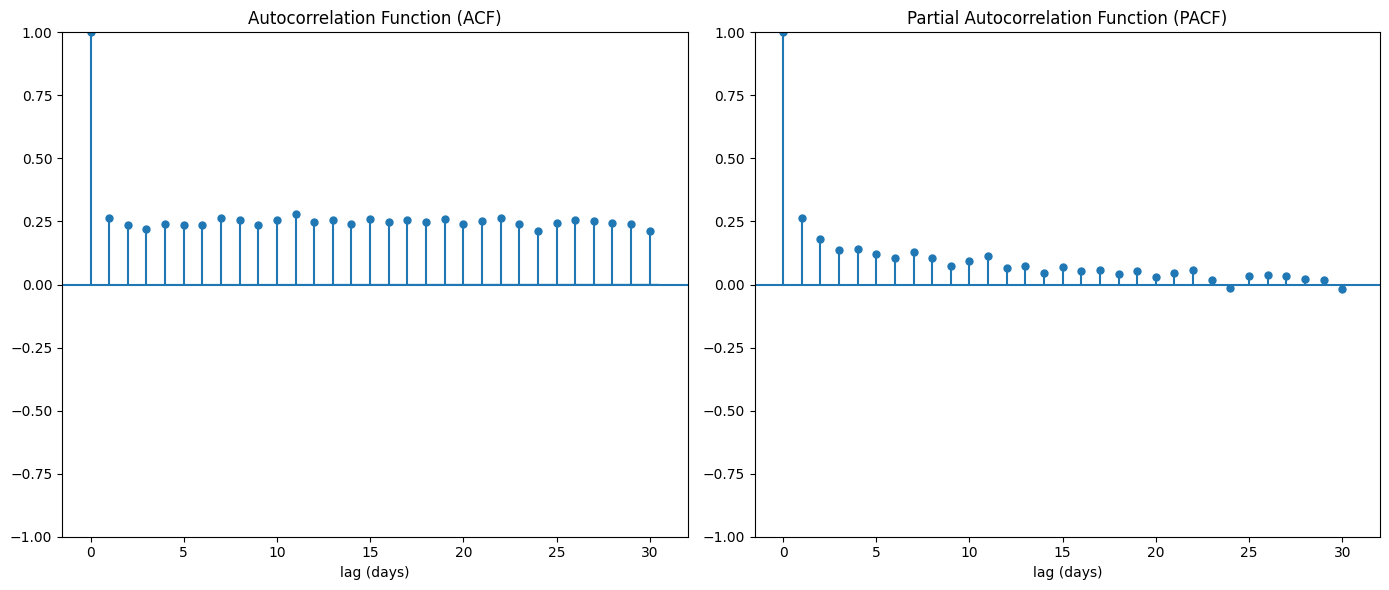


=== AUTOCORRELATION INSIGHTS ===
Look for:
- Spikes at lag 7, 14, 21 (weekly pattern)
- High correlation at lag 1 (yesterday predicts today)


In [11]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

fig,ax = plt.subplots(1,2,figsize = (14,6))

plot_acf(store_1_open['Sales'].dropna(),lags = 30,ax = ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')
ax[0].set_xlabel('lag (days)')          

plot_pacf(store_1_open['Sales'].dropna(),lags = 30 ,ax=ax[1],method = 'ols')
ax[1].set_title('Partial Autocorrelation Function (PACF)')
ax[1].set_xlabel('lag (days)')
plt.tight_layout()
plt.show()


print("\n=== AUTOCORRELATION INSIGHTS ===")
print("Look for:")
print("- Spikes at lag 7, 14, 21 (weekly pattern)")
print("- High correlation at lag 1 (yesterday predicts today)")

In [12]:
def create_lag_features(df,lags = [1,2,3,7,14]):
    df = df.copy()
    for lag in lags:
        df[f'Sales_lag{lag}'] = df['Sales'].shift(lag)
    return df
store_1_features = create_lag_features(store_1_open.reset_index(),lags = [1,7,14,21,28])
print('Lag Features')
#print(store_1_features.columns.tolist())
print(store_1_features[['Date','Store','Sales_lag1','Sales_lag7','Sales_lag14','Sales_lag21','Sales_lag28']].head(30))

Lag Features
         Date  Store  Sales_lag1  Sales_lag7  Sales_lag14  Sales_lag21  \
0  2015-07-31      1         NaN         NaN          NaN          NaN   
1  2015-07-31      2      5263.0         NaN          NaN          NaN   
2  2015-07-31      3      6064.0         NaN          NaN          NaN   
3  2015-07-31      4      8314.0         NaN          NaN          NaN   
4  2015-07-31      5     13995.0         NaN          NaN          NaN   
5  2015-07-31      6      4822.0         NaN          NaN          NaN   
6  2015-07-31      7      5651.0         NaN          NaN          NaN   
7  2015-07-31      8     15344.0      5263.0          NaN          NaN   
8  2015-07-31      9      8492.0      6064.0          NaN          NaN   
9  2015-07-31     10      8565.0      8314.0          NaN          NaN   
10 2015-07-31     11      7185.0     13995.0          NaN          NaN   
11 2015-07-31     12     10457.0      4822.0          NaN          NaN   
12 2015-07-31     13     

In [13]:
print('Correlation with Lags: ')
lag_cols = [col for col in store_1_features.columns if 'Sales_lag' in col]
correlations = store_1_features[['Sales'] + lag_cols].corr()['Sales'].sort_values(ascending = False)
print(correlations)

Correlation with Lags: 
Sales          1.000000
Sales_lag7     0.261954
Sales_lag1     0.261872
Sales_lag21    0.253311
Sales_lag28    0.242287
Sales_lag14    0.238832
Name: Sales, dtype: float64


In [14]:
store_1_features['Sales_RollingMean7'] = store_1_features['Sales'].rolling(window=7).mean()
store_1_features['Sales_RollingStd7']  = store_1_features['Sales'].rolling(window=7).std()
print('Rolling Statistics')
print(store_1_features[['Date','Store','Sales_RollingMean7','Sales_RollingStd7']].head(15))

Rolling Statistics
         Date  Store  Sales_RollingMean7  Sales_RollingStd7
0  2015-07-31      1                 NaN                NaN
1  2015-07-31      2                 NaN                NaN
2  2015-07-31      3                 NaN                NaN
3  2015-07-31      4                 NaN                NaN
4  2015-07-31      5                 NaN                NaN
5  2015-07-31      6                 NaN                NaN
6  2015-07-31      7         8493.285714        4380.380338
7  2015-07-31      8         8954.571429        4147.331586
8  2015-07-31      9         9311.857143        3960.322943
9  2015-07-31     10         9150.571429        4030.108719
10 2015-07-31     11         8645.142857        3509.527956
11 2015-07-31     12         9236.142857        3080.525844
12 2015-07-31     13         9689.000000        2671.496896
13 2015-07-31     14         8431.857143        1269.548270
14 2015-07-31     15         8531.714286        1302.139101


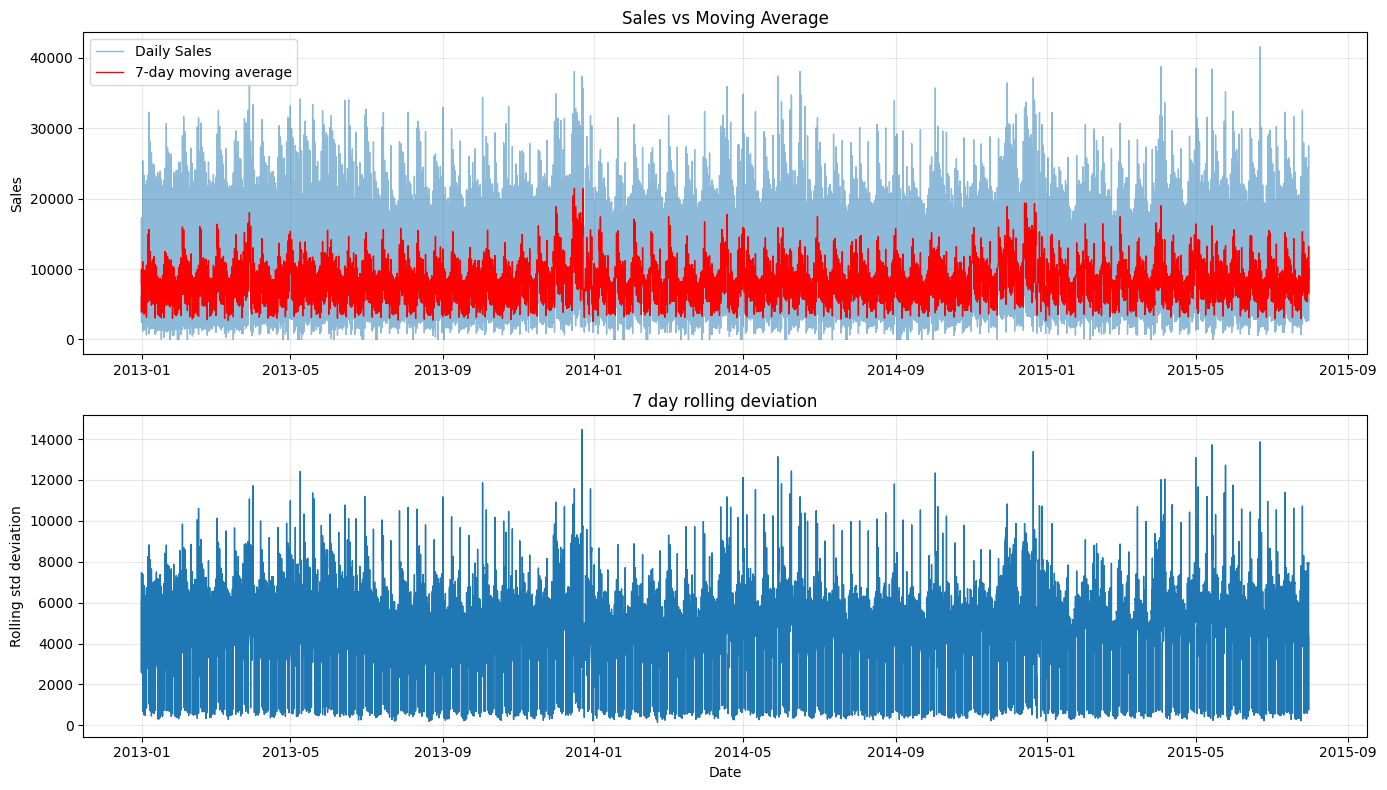

In [15]:
fig,axes = plt.subplots(2,1,figsize = (14,8))


# Sales vs 7-day moving average
axes[0].plot(store_1_features['Date'],store_1_features['Sales'],linewidth = 1,alpha = 0.5,label = 'Daily Sales')
axes[0].plot(store_1_features['Date'],store_1_features['Sales_RollingMean7'],linewidth = 1, color = 'red',label = '7-day moving average')
axes[0].set_ylabel('Sales')
axes[0].set_title('Sales vs Moving Average')
axes[0].legend()
axes[0].grid(alpha = 0.3)


# Rolling standard deviation
axes[1].plot(store_1_features['Date'],store_1_features['Sales_RollingStd7'],linewidth = 1)
axes[1].set_ylabel('Rolling std deviation')
axes[1].set_xlabel('Date')
axes[1].set_title('7 day rolling deviation')
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

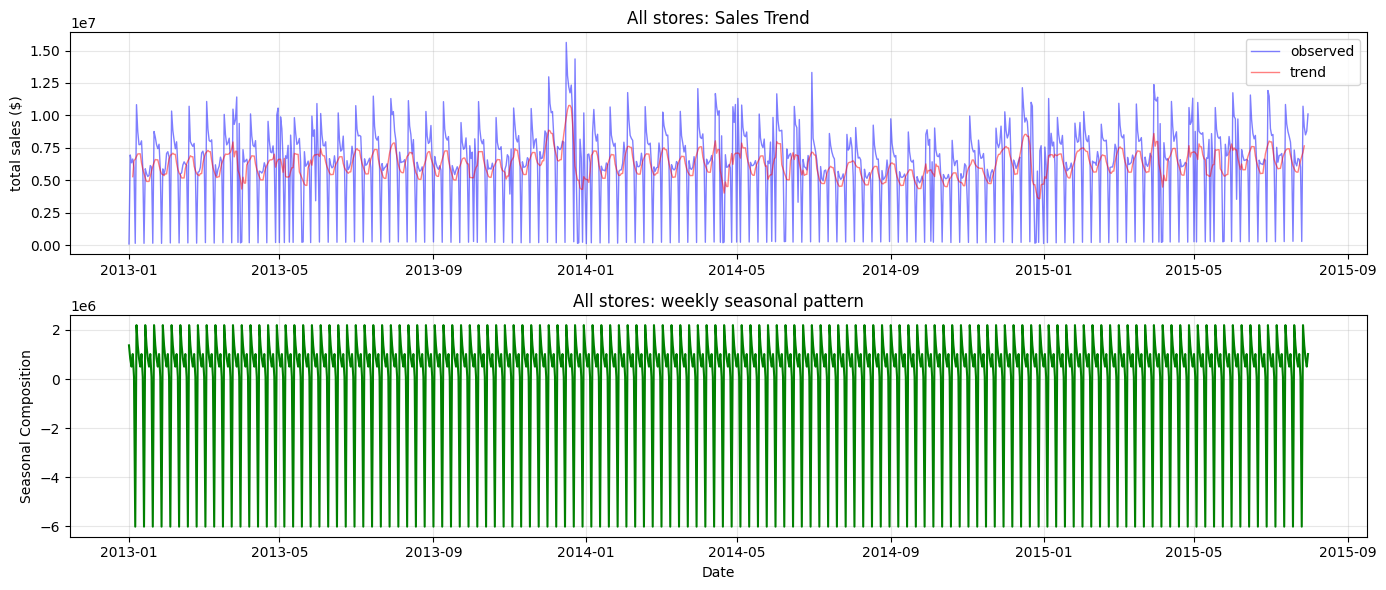

overall trend analysis
trend at start (2013) 5,279,455
trend at end (2015) 7,648,351
change +44.9%
seasonal patern (all stores)
day: Monday       : +1,373,627.37
day: Tuesday      :  +833,860.28
day: Wednesday    :  +506,775.19
day: Thursday     : +1,019,054.15
day: Friday       :   +83,108.43
day: Saturday     : -6,013,815.07
day: Sunday       : +2,197,389.64


In [16]:
all_store_daily = train_full.groupby('Date').agg({
    'Sales' : ['sum','mean','std'],
    'Open'  : 'sum'
}).reset_index()

all_store_daily.columns = ['Date','TotalSales','AvgSales','StdSales','TotalStoresOpen']
all_store_series = all_store_daily.set_index('Date')['TotalSales']
all_decomp = seasonal_decompose(all_store_series,model = 'additive',period = 7)

fig,axes = plt.subplots(2,1,figsize = (14,6))
axes[0].plot(all_decomp.observed.index,all_decomp.observed,linewidth = 1,alpha = 0.5,label = 'observed',color = 'blue')
axes[0].plot(all_decomp.trend.index,all_decomp.trend,linewidth = 1, alpha = 0.5,label = 'trend',color = 'red')
axes[0].set_ylabel('total sales ($)')
axes[0].set_title('All stores: Sales Trend')
axes[0].legend()
axes[0].grid(alpha = 0.3)

axes[1].plot(all_decomp.seasonal.index,all_decomp.seasonal,color = 'green')
axes[1].set_ylabel('Seasonal Composition')
axes[1].set_xlabel('Date')
axes[1].set_title('All stores: weekly seasonal pattern')
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

print(f'overall trend analysis')
print(f'trend at start (2013) {all_decomp.trend.dropna().iloc[0]:,.0f}')
print(f'trend at end (2015) {all_decomp.trend.dropna().iloc[-1]:,.0f}')
change = ((all_decomp.trend.dropna().iloc[-1] - all_decomp.trend.dropna().iloc[0]) / all_decomp.trend.dropna().iloc[0] * 100)
print(f'change {change:+.1f}%')

print(f'seasonal patern (all stores)')
seasonal_weekly = all_decomp.seasonal.iloc[:7].values

for day,value in zip(days,seasonal_weekly):
    print(f'day: {day:12s} : {value:+12,.2f}')

## Day 2: Trend & Seasonality Decomposition Summary

### Seasonal Decomposition Components
- **Original:** Jagged daily sales pattern
- **Trend:** **Growing 44.9%** from €5.3M (2013) to €7.6M (2015)
- **Seasonal:** Weekly pattern repeating (range: -€6M to +€2M)
- **Residual:** Random noise, std = €2,507

### Business Growth Discovery
- **2013 daily sales: €5.3M** across all stores
- **2015 daily sales: €7.6M** across all stores
- **Growth: +44.9%** - business expanding rapidly
- This trend should be captured in forecasting models

### Weekly Seasonal Pattern (Store 1)
- **Monday: +€11.74** - Best day (post-weekend restocking)
- **Thursday: +€7.42** - Mid-week boost
- **Tuesday: -€8.25** - Worst day (post-Monday lull)

### Weekly Seasonal Pattern (All Stores)
- **Monday: +€1.37M** - Biggest boost
- **Saturday: -€6.01M** - Many stores closed
- Much stronger pattern than individual stores (includes closures)

### Autocorrelation Analysis
- **Lag 1 (yesterday): 0.262** - Yesterday predicts today
- **Lag 7 (last week): 0.262** - Weekly cycle equally strong
- **PACF shows:** Direct dependencies only go back ~2 days

### Feature Engineering Created
**Lag features:** Sales_Lag1, Sales_Lag7, Sales_Lag14, Sales_Lag21, Sales_Lag28
- Yesterday and last week equally predictive (both 0.26)

**Rolling statistics:**
- 7-day moving average: Smooths noise, reveals trend
- 7-day rolling std: Captures volatility (€5K-€14K during holidays)

### Key Takeaways
1. **Business is growing 45% over 2.5 years** - strong upward trend
2. **Time series has memory** - yesterday matters
3. **Weekly seasonality is dominant** - same day last week predicts today
4. **Store-specific patterns exist** - Don't only use global averages
5. **Volatility varies** - Christmas = high uncertainty

### Tomorrow: Feature Engineering
Create date-based features (month, day of week, holidays) for ML modeling.

In [17]:
train_full['Date'] = pd.to_datetime(train_full['Date'])

train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['Day']   = train_full['Date'].dt.day
train_full['DayOfYear'] = train_full['Date'].dt.dayofyear
train_full['WeekOfYear'] = train_full['Date'].dt.isocalendar().week
train_full['Quarter'] = train_full['Date'].dt.quarter

print('Date Features Created')

print(train_full[['Date','Year','Month','Day','DayOfYear','WeekOfYear','Quarter']].head(10))
print('Feature Distribution')
print(f'Year: {train_full['Year'].unique()}')
print(f'Months: {sorted(train_full['Month'].unique())}')
print(f'Days of week: {sorted(train_full['DayOfWeek'].unique())}')
print(f'Quarters: {sorted(train_full['Quarter'].unique())}')

Date Features Created
        Date  Year  Month  Day  DayOfYear  WeekOfYear  Quarter
0 2015-07-31  2015      7   31        212          31        3
1 2015-07-31  2015      7   31        212          31        3
2 2015-07-31  2015      7   31        212          31        3
3 2015-07-31  2015      7   31        212          31        3
4 2015-07-31  2015      7   31        212          31        3
5 2015-07-31  2015      7   31        212          31        3
6 2015-07-31  2015      7   31        212          31        3
7 2015-07-31  2015      7   31        212          31        3
8 2015-07-31  2015      7   31        212          31        3
9 2015-07-31  2015      7   31        212          31        3
Feature Distribution
Year: [2015 2014 2013]
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Days of week: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int

In [18]:
# Problem: Month 1 and Month 12 are adjacent but model sees them as far apart (1 vs 12)
# Solution: Encode as sin/cos (cyclical)

train_full['Month_sin'] = np.sin(2 * np.pi * train_full['Month'] / 12)
train_full['Month_cos'] = np.cos(2 * np.pi * train_full['Month'] / 12)

train_full['DayOfWeek_sin'] = np.sin(2 * np.pi * train_full['DayOfWeek'] / 7)
train_full['DayOfWeek_cos'] = np.cos(2 * np.pi * train_full['DayOfWeek'] / 7)

print('Cyclical Encoding')
print("Month encoding (December and January are now close):")
print(train_full[train_full['Month'].isin([1,12])][['Month','Month_sin','Month_cos']].drop_duplicates().sort_values('Month'))

Cyclical Encoding
Month encoding (December and January are now close):
        Month     Month_sin  Month_cos
201815      1  5.000000e-01   0.866025
236380     12 -2.449294e-16   1.000000


Text(0.5, 1.0, 'Cyclical Day of week Encoding')

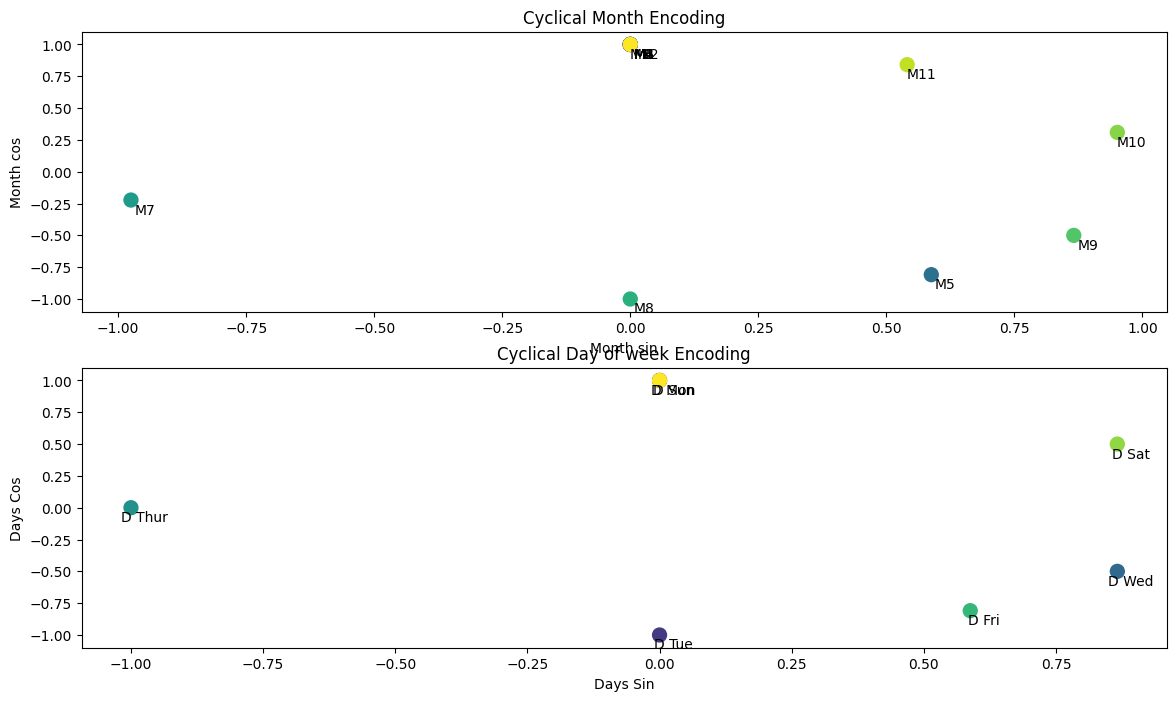

In [19]:
fig,ax = plt.subplots(2,1,figsize = (14,8))

months = np.arange(1,13)
months_sin = np.sin(2 * np.pi / months * 12)
months_cos = np.cos(2 * np.pi / months * 12)

ax[0].scatter(months_sin,months_cos,c = months,cmap = 'viridis',s = 100)
for i,month in enumerate(months):
    ax[0].annotate(f'M{month}',(months_sin[i],months_cos[i]),ha = 'center',fontsize = 10,xytext = (10,-10),textcoords = 'offset points')
ax[0].set_xlabel('Month sin')
ax[0].set_ylabel('Month cos')
ax[0].set_title('Cyclical Month Encoding')

days = np.arange(1,8)
days_sin = np.sin(2 * np.pi / days * 7)
days_cos = np.cos(2 * np.pi / days * 7)

ax[1].scatter(days_sin,days_cos,c = days,cmap = 'viridis',s = 100)
days_names = ['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun']
for i,day in enumerate(days_names):
    ax[1].annotate(f'D {day}',(days_sin[i],days_cos[i]),ha = 'center',xytext = (10,-10),textcoords = 'offset points')
ax[1].set_xlabel('Days Sin')
ax[1].set_ylabel('Days Cos')
ax[1].set_title('Cyclical Day of week Encoding')

In [20]:
print('Holiday Analysis')
print('State Holidays: ')
print(train_full['StateHoliday'].value_counts())
print('School Holidays: ')
print(train_full['SchoolHoliday'].value_counts())

train_full['IsStateHoliday'] = (train_full['StateHoliday'] != '0').astype(int)
train_full['IsChristmas'] = (train_full['StateHoliday'] == 'c').astype(int)
train_full['IsEaster'] = (train_full['StateHoliday'] == 'b').astype(int)

train_full['IsSchoolHoliday'] = train_full['SchoolHoliday']

print('\nHoliday Features')
print(f'State holidays: {train_full['IsStateHoliday'].sum():,}')
print(f'Chrishtmas holidays: {train_full['IsChristmas'].sum():,}')
print(f'Easter Holidays: {train_full['IsEaster'].sum():,}')
print(f'School Holidays: {train_full['IsSchoolHoliday'].sum():,}')

print('\nHoliday impact on sales')
holiday_impact = train_full.groupby('IsStateHoliday')['Sales'].mean()
print(f'No state Holiday {holiday_impact[0]:,.2f}$')
print(f'State Holiday {holiday_impact[1]:,.2f}$')
print(f'Impact: {(holiday_impact[1] / holiday_impact[0] - 1 ) * 100:+.2f}%')

Holiday Analysis
State Holidays: 
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64
School Holidays: 
SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

Holiday Features
State holidays: 31,050
Chrishtmas holidays: 4,100
Easter Holidays: 6,690
School Holidays: 181,721

Holiday impact on sales
No state Holiday 5,947.48$
State Holiday 258.16$
Impact: -95.66%


In [21]:
print('Promotion Analysis')
print(f'Promo on {train_full['Promo'].sum():,} days({train_full['Promo'].mean() * 100:.2f}%)')
print(f'Promo 2 (continuous): {train_full['Promo2'].sum():,}')
promo_impact = train_full.groupby('Promo')['Sales'].mean()
print(f'No Promo impact {promo_impact[0]:.2f}')
print(f'Promo impact {promo_impact[1]:.2f}')
print(f'Boost impact {(promo_impact[1] / promo_impact[0] - 1) * 100:.2f}%')

Promotion Analysis
Promo on 388,080 days(38.15%)
Promo 2 (continuous): 509,178
No Promo impact 4406.05
Promo impact 7991.15
Boost impact 81.37%


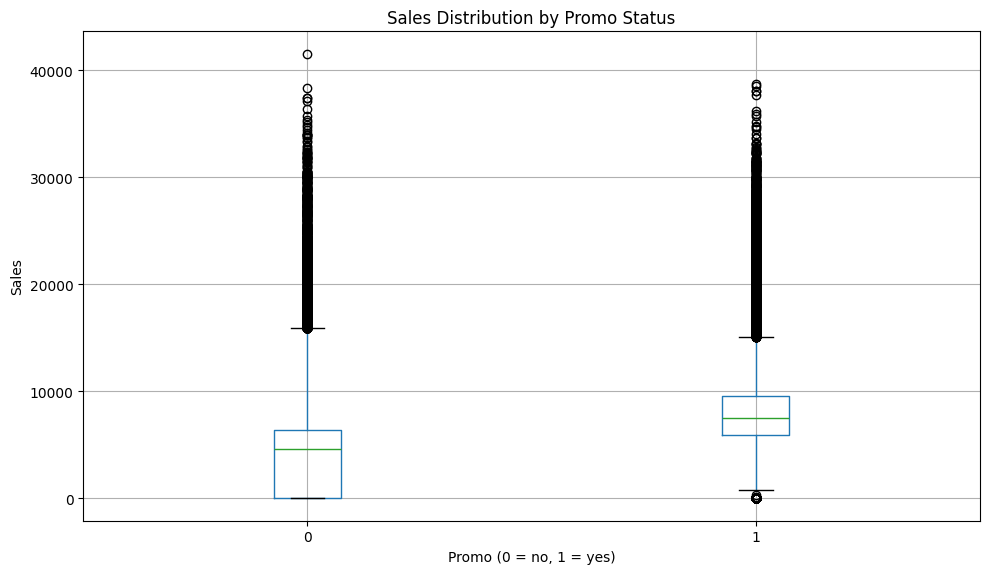

In [22]:
fig , ax = plt.subplots(figsize = (10,6))
train_full.boxplot(column = 'Sales',by = 'Promo',ax=ax)
ax.set_xlabel('Promo (0 = no, 1 = yes)')
ax.set_ylabel('Sales')
ax.set_title('Sales Distribution by Promo Status')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [42]:
print('Store type impact:')
store_type_sales = train_full.groupby('StoreType')['Sales'].agg(['mean','count'])
print(store_type_sales.sort_values('mean',ascending = False))

store_average_sale = train_full.groupby('Store')['Sales'].mean().to_dict()
train_full['StoreAvgSale'] = train_full['Store'].map(store_average_sale)
print('store average sale')
print(f'from {train_full['StoreAvgSale'].min():.2f}$ to {train_full['StoreAvgSale'].max():.2f}$')
print('Missing Competition data: ')
print(train_full['CompetitionDistance'].isna().sum())


# filling none as a big number since there are no near competiotion stores
train_full['CompetitionDistance'] = train_full['CompetitionDistance'].fillna(999999)

#competition near < 10km
train_full['HasCompetition'] = (train_full['CompetitionDistance'] < 10000).astype(int)
print(f'stores with competition < 10km: {train_full['HasCompetition'].sum():,}')

Store type impact:
                   mean   count
StoreType                      
b          10058.837334   15830
a           5738.179710  551627
c           5723.629246  136840
d           5641.819243  312912
store average sale
from 2244.50$ to 20718.52$
Missing Competition data: 
0
stores with competition < 10km: 843,381


In [46]:
train_full.head()
print(train_full.columns.tolist())
feature_cols = [
    #date columns
    'Year','Month','Day','DayOfYear','DayOfWeek','WeekOfYear', 'Quarter', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos',
    #promo columns
    'Promo','Promo2',
    #store columns
    'CompetitionDistance','StoreAvgSale', 'HasCompetition','Store','StoreType', 'Assortment',
    #holiday columns
    'IsStateHoliday', 'IsChristmas', 'IsEaster', 'IsSchoolHoliday', 
    #for filtering
    'Customers', 'Open',]


['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'DayOfYear', 'WeekOfYear', 'Quarter', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'IsStateHoliday', 'IsChristmas', 'IsEaster', 'IsSchoolHoliday', 'StoreAvgSale', 'HasCompetition']


In [52]:
features_df = train_full[feature_cols + ['Sales','Date']]
print('feature matrix created')
print(f'feature shape {features_df.shape}')
print(f'features {len(features_df)}')
print('feature list: ')
for i,feat in enumerate(features_df):
    print(f'{i:2d}. {feat}')

feature matrix created
feature shape (1017209, 27)
features 1017209
feature list: 
 0 Year
 1 Month
 2 Day
 3 DayOfYear
 4 DayOfWeek
 5 WeekOfYear
 6 Quarter
 7 Month_sin
 8 Month_cos
 9 DayOfWeek_sin
10 DayOfWeek_cos
11 Promo
12 Promo2
13 Store
14 StoreType
15 Assortment
16 IsStateHoliday
17 IsChristmas
18 IsEaster
19 IsSchoolHoliday
20 CompetitionDistance
21 StoreAvgSale
22 HasCompetition
23 Customers
24 Open
25 Sales
26 Date


In [72]:
print('categorical features')
cat_features = ['StoreType','Assortment']
for feat in cat_features:
    print(f'{feat} in {features_df[feat].unique()}')

features_encoded = pd.get_dummies(features_df,columns=cat_features,drop_first=True)
print('After Encoding')
print(features_encoded.shape)
print(f'new features created {features_encoded.shape[1] - features_df.shape[1]} from one-hot encoding')
print('first few rows')
print(features_encoded.head())

categorical features
StoreType in <StringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str
Assortment in <StringArray>
['a', 'c', 'b']
Length: 3, dtype: str
After Encoding
(1017209, 30)
new features created 3 from one-hot encoding
first few rows
   Year  Month  Day  DayOfYear  DayOfWeek  WeekOfYear  Quarter  Month_sin  \
0  2015      7   31        212          5          31        3       -0.5   
1  2015      7   31        212          5          31        3       -0.5   
2  2015      7   31        212          5          31        3       -0.5   
3  2015      7   31        212          5          31        3       -0.5   
4  2015      7   31        212          5          31        3       -0.5   

   Month_cos  DayOfWeek_sin  DayOfWeek_cos  Promo  Promo2  Store  \
0  -0.866025      -0.974928      -0.222521      1       0      1   
1  -0.866025      -0.974928      -0.222521      1       1      2   
2  -0.866025      -0.974928      -0.222521      1       1      3   
3  -0.866025      -

## Day 3: Advanced Feature Engineering Summary

### Date-Based Features Created
- **Time components:** Year, Month, Day, DayOfYear, WeekOfYear, Quarter, DayOfWeek
- **Cyclical encoding:** Month_sin/cos, DayOfWeek_sin/cos
- **Why cyclical?** December (12) and January (1) are now neighbors on a circle

### Holiday Features - MAJOR DISCOVERY
- **State holidays: -95.66% impact** - stores CLOSED on public holidays
- Christmas: 4,100 days
- Easter: 6,690 days  
- School holidays: 181,721 days
- **Key insight:** Must filter out closed days or model will predict €0 incorrectly

### Promotion Features - MASSIVE IMPACT
- **Promotions boost sales +81.37%** (€4,406 → €7,991)
- Running on 38% of days
- Promo is the most powerful feature discovered
- Promo2 (continuous): 509,178 store-days

### Store-Specific Features
- **Store size proxy:** Average sales per store (€2,244 to €20,718)
- **9x variation** between smallest and largest stores
- Competition distance: 999,999 = no nearby competition
- HasCompetition: 843,381 days with competition <10km

### Feature Matrix
- **Before encoding:** 27 features
- **After one-hot encoding:** 30 features
  - StoreType_b, StoreType_c, StoreType_d
  - Assortment_b, Assortment_c
- **Ready for modeling**

### Feature Categories
1. **Time features (11):** Year, Month, Day, DayOfYear, DayOfWeek, WeekOfYear, Quarter, Month_sin/cos, DayOfWeek_sin/cos
2. **Holiday features (4):** IsStateHoliday, IsChristmas, IsEaster, IsSchoolHoliday
3. **Promotion features (2):** Promo, Promo2
4. **Store features (9):** Store, StoreType (one-hot), Assortment (one-hot), CompetitionDistance, StoreAvgSale, HasCompetition
5. **Context features (2):** Open, Customers

### Key Takeaways
1. **Promotions are gold** - +81% sales boost
2. **State holidays = closed stores** - must handle carefully
3. **Store variation is huge** - 9x difference in average sales
4. **Cyclical encoding matters** - helps model understand December→January transition
5. **30 engineered features** from 9 raw columns

### Tomorrow: Baseline Model
Add lag features, train XGBoost, evaluate performance with proper time-based train/test split.